Saving archive (24).zip to archive (24) (1).zip


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2557
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0303
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 10/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035
Epoch 11/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036
Epoch 12/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035
Epoch 13/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035
Epoch 14/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035
Epoch 15/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034
Epoch 16/30
37/37 ━

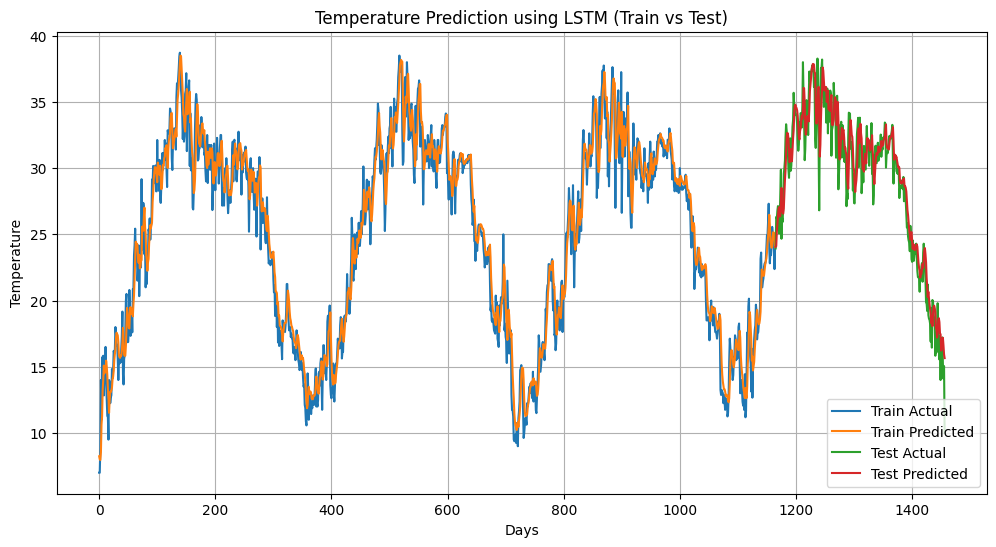

In [2]:
# 1. Upload dataset
from google.colab import files
uploaded = files.upload()

# Extract the zip file contents
import zipfile
for fn in uploaded.keys():
  with zipfile.ZipFile(fn, 'r') as zip_ref:
    zip_ref.extractall('.')

# 2. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# 3. Load dataset
df = pd.read_csv('DailyDelhiClimateTrain.csv')

# Use only temperature column
data = df['meantemp'].values.reshape(-1, 1)

# 4. Normalize data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# 5. Create dataset (time-series)
def create_data(data, steps=5):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i:i+steps])
        y.append(data[i+steps])
    return np.array(X), np.array(y)

X, y = create_data(data, 5)

# 6. Train-Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 7. Build LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(5,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# 8. Train model
model.fit(X_train, y_train, epochs=30, verbose=1)

# 9. Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Convert back to original values
train_pred = scaler.inverse_transform(train_pred)
y_train = scaler.inverse_transform(y_train)

test_pred = scaler.inverse_transform(test_pred)
y_test = scaler.inverse_transform(y_test)

# 10. Plot graph
plt.figure(figsize=(12,6))

plt.plot(range(len(y_train)), y_train, label="Train Actual")
plt.plot(range(len(train_pred)), train_pred, label="Train Predicted")

plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test, label="Test Actual")
plt.plot(range(len(y_train), len(y_train)+len(test_pred)), test_pred, label="Test Predicted")

plt.title("Temperature Prediction using LSTM (Train vs Test)")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.legend()
plt.grid()

plt.show()